# Basic Chat Bot
powered by `LangGraph (Graph API)`

In [1]:
# Importing libraries

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # REDUCERS -> appending messages (creating a history)

/Users/soubhiksinha/GitHub/Agentic-AI-LangGraph-and-MCP/.venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [2]:
# Creating State
from typing import Annotated

class State(TypedDict):
  messages: Annotated[list, add_messages]

In [3]:
# Loading environment variable values

import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
''' 
Defining LLMs
'''

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

# Loading model
llm = ChatGroq(model = "llama-3.1-8b-instant")

In [5]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1096a9520>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10980e180>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Another way of loading LLM
'''
llm = init_chat_model("groq:llama-3.1-8b-instant")
'''

'\nllm = init_chat_model("groq:llama-3.1-8b-instant")\n'

In [7]:
# Creating Node definitions

def chatbot(state:State):
  return {"messages": [llm.invoke(state["messages"])]}

In [8]:
# Creating Graph
graph_builder = StateGraph(State)

In [9]:
graph_builder.add_node("llmChatBot", chatbot)

# Adding Edge(s)
graph_builder.add_edge(START, "llmChatBot")
graph_builder.add_edge("llmChatBot", END)

In [10]:
# Compiling the Graph
graph = graph_builder.compile()

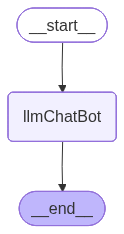

In [11]:
graph

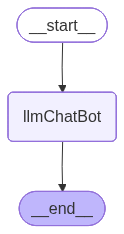

In [12]:
# Another way of showing the graph

from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [13]:
# Running the workflow (invoking)

response = graph.invoke({"messages": "Hi! This is Rick!!!"})

In [14]:
response

{'messages': [HumanMessage(content='Hi! This is Rick!!!', additional_kwargs={}, response_metadata={}, id='494df7b7-8f0a-41f4-a5b5-589ee88df1c0'),
  AIMessage(content="Nice to meet you, Rick! What's on your mind, or would you like to chat about something in particular?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 41, 'total_tokens': 66, 'completion_time': 0.067563665, 'completion_tokens_details': None, 'prompt_time': 0.315831425, 'prompt_tokens_details': None, 'queue_time': 0.284354059, 'total_time': 0.38339509}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfabd-1cdd-7263-9f20-3ad4eb76afb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 25, 'total_tokens': 66})]}

In [15]:
response["messages"]

[HumanMessage(content='Hi! This is Rick!!!', additional_kwargs={}, response_metadata={}, id='494df7b7-8f0a-41f4-a5b5-589ee88df1c0'),
 AIMessage(content="Nice to meet you, Rick! What's on your mind, or would you like to chat about something in particular?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 41, 'total_tokens': 66, 'completion_time': 0.067563665, 'completion_tokens_details': None, 'prompt_time': 0.315831425, 'prompt_tokens_details': None, 'queue_time': 0.284354059, 'total_time': 0.38339509}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfabd-1cdd-7263-9f20-3ad4eb76afb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 25, 'total_tokens': 66})]

In [16]:
response["messages"][-1]

AIMessage(content="Nice to meet you, Rick! What's on your mind, or would you like to chat about something in particular?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 25, 'prompt_tokens': 41, 'total_tokens': 66, 'completion_time': 0.067563665, 'completion_tokens_details': None, 'prompt_time': 0.315831425, 'prompt_tokens_details': None, 'queue_time': 0.284354059, 'total_time': 0.38339509}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfabd-1cdd-7263-9f20-3ad4eb76afb6-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 25, 'total_tokens': 66})

In [17]:
response["messages"][-1].content

"Nice to meet you, Rick! What's on your mind, or would you like to chat about something in particular?"

In [18]:
for event in graph.stream({"messages": "Hi! This is Rick!! How's everything going ?"}):
  print(event)


{'llmChatBot': {'messages': [AIMessage(content="Nice to meet you, Rick! I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 59, 'prompt_tokens': 46, 'total_tokens': 105, 'completion_time': 0.148798897, 'completion_tokens_details': None, 'prompt_time': 0.004497734, 'prompt_tokens_details': None, 'queue_time': 0.0074134, 'total_time': 0.153296631}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfabd-1ff5-7ca0-b18e-d3a9b7684c51-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 59, 'total_tokens': 105})]}}


In [19]:
for event in graph.stream({"messages": "Hi! This is Rick!! How's everything going ?"}):
  for value in event.values():
    print(value["messages"][-1].content)

Nice to meet you, Rick! Everything is going well here. I'm a large language model, so I don't have emotions or personal experiences, but I'm always happy to chat with you and help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


<br>

## Chat-Bot with Tool(s)

In [20]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)
tool.invoke("WHat is LangGraph ?")

{'query': 'WHat is LangGraph ?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://huggingface.co/learn/agents-course/unit2/langgraph/when_to_use_langgraph',
   'title': 'What is LangGraph - Hugging Face',
   'content': '`LangGraph` is a framework developed by LangChain **to manage the control flow of applications that integrate an LLM**. ## Is LangGraph different from LangChain ? The classes from LangChain might be used in LangGraph, but do not HAVE to be used. The packages are different and can be used in isolation, but, in the end, all resources you will find online use both packages hand in hand. `LangGraph` is on the other end of the spectrum, it shines when you need **“Control”** on the execution of your agent. LangGraph is particularly valuable when you need **Control over your applications**. It gives you the tools to build an application that follows a predictable process while still leveraging the power of LLMs. Put simply, if your ap

In [21]:
# Creating a custom function

def multiply(a: int, b: int) -> int:
  """Multiply a and b

  Args:
    a (int) : first int
    b (int) : second int
  
  Returns:
    int: output int
  """
  return a*b


In [22]:
tools = [tool, multiply]

In [23]:
llm_with_tool = llm.bind_tools(tools)

In [24]:
llm_with_tool

RunnableBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x1096a9520>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x10980e180>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool delivers real-time, acc

In [25]:
# StateGraph

from langgraph.prebuilt import ToolNode, tools_condition

In [26]:
# The above created functions must be converted to Tool Nodes

# Node Defintion
def tool_calling_llm(state: State):
  return {"messages" :[llm_with_tool.invoke(state["messages"])]}

# Creating the Graph (Adding Nodes)
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# Adding Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
  # If the latest message (result) from assistant is a NOT a tool call --> tools_condition routes to END
  tools_condition
)
builder.add_edge("tools", END)

# Compiling the graph
graph = builder.compile()

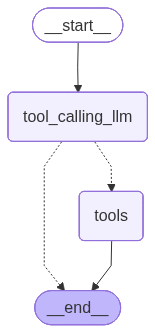

In [27]:
graph

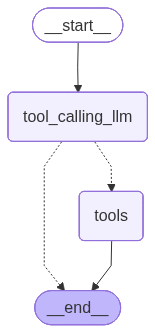

In [28]:
# Showing the graph another way

from IPython.display import Image, display

try:
  display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [29]:
# Invoke the graph (workflow)

response = graph.invoke({"messages" : "What are the recent advances in Agentic AI ?"})

In [30]:
response

{'messages': [HumanMessage(content='What are the recent advances in Agentic AI ?', additional_kwargs={}, response_metadata={}, id='8881571a-5bee-46f3-8574-239d7ca3c8d1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'arsdd6rpv', 'function': {'arguments': '{"query":"Recent advances in Agentic AI","search_depth":"advanced","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 1755, 'total_tokens': 1787, 'completion_time': 0.055315377, 'completion_tokens_details': None, 'prompt_time': 0.127121973, 'prompt_tokens_details': None, 'queue_time': 0.006467729, 'total_time': 0.18243735}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_e2c608b1d6', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfabd-236a-7030-96d4-98efcfee18c2-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Recent advanc

In [31]:
response["messages"][-1].content

'{"query": "Recent advances in Agentic AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.prnewswire.com/news-releases/appier-advances-ai-self-awareness-to-unlock-enterprise-roi-302757039.html", "title": "Appier Advances AI Self-Awareness to Unlock Enterprise ROI - PR Newswire", "score": 0.9997428, "published_date": "Wed, 29 Apr 2026 09:40:00 GMT", "content": "Appier, an AI-native Agentic AI as a Service (AaaS) company, today announced new research from its global AI team focused on a critical capability: AI self-awareness. The research enables AI to ask more precisely, assess risk, and recognize the limits of its own knowledge. These capabilities are embedded across its Ad Cloud, Personalization Cloud, and Data Cloud—accelerating the transition from usable AI to trustworthy AI, and positioning AI as a reliable decision partner for enterprises. [...] Appier has long invested in academic–industry collaboration and frontier research, publishi

In [32]:
for m in response["messages"]:
  m.pretty_print()

================================ Human Message =================================

What are the recent advances in Agentic AI ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (arsdd6rpv)
 Call ID: arsdd6rpv
  Args:
    query: Recent advances in Agentic AI
    search_depth: advanced
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "Recent advances in Agentic AI", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.prnewswire.com/news-releases/appier-advances-ai-self-awareness-to-unlock-enterprise-roi-302757039.html", "title": "Appier Advances AI Self-Awareness to Unlock Enterprise ROI - PR Newswire", "score": 0.9997428, "published_date": "Wed, 29 Apr 2026 09:40:00 GMT", "content": "Appier, an AI-native Agentic AI as a Service (AaaS) company, today announced new research from its global AI team focused on a cri

In [33]:
response1 = graph.invoke({"messages" : "2 X 3 = ?"})

In [34]:
response1

{'messages': [HumanMessage(content='2 X 3 = ?', additional_kwargs={}, response_metadata={}, id='29ade6d8-9fe5-4a2c-8c40-fe55ae9023e1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '1evwb97d5', 'function': {'arguments': '{"a":2,"b":3}', 'name': 'multiply'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1751, 'total_tokens': 1770, 'completion_time': 0.034621339, 'completion_tokens_details': None, 'prompt_time': 0.135275003, 'prompt_tokens_details': None, 'queue_time': 0.134811246, 'total_time': 0.169896342}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4848f70c04', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfabd-65b0-73f0-9401-6b637cc3f492-0', tool_calls=[{'name': 'multiply', 'args': {'a': 2, 'b': 3}, 'id': '1evwb97d5', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1751, 'output_tokens':

In [35]:
response1["messages"][-1].content

'6'

In [36]:
for m in response1["messages"]:
  m.pretty_print()

================================ Human Message =================================

2 X 3 = ?
================================== Ai Message ==================================
Tool Calls:
  multiply (1evwb97d5)
 Call ID: 1evwb97d5
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [37]:
response2 = graph.invoke({"messages" : "What is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response2["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  multiply (cfdf84pmr)
 Call ID: cfdf84pmr
  Args:
    a: 2
    b: 5
  multiply (sfw9qhtzq)
 Call ID: sfw9qhtzq
  Args:
    a: 10
    b: 100
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

1000


In [38]:
response3 = graph.invoke({"messages" : "What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response3["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  tavily_search (7k7xh8hcp)
 Call ID: 7k7xh8hcp
  Args:
    include_images: False
    query: latest news by Apple Inc.
    search_depth: advanced
    topic: news
  multiply (snqc3mp9q)
 Call ID: snqc3mp9q
  Args:
    a: 2
    b: 5
  multiply (kawpej7h4)
 Call ID: kawpej7h4
  Args:
    a: 10
    b: 100
================================= Tool Message =================================
Name: tavily_search

{"query": "latest news by Apple Inc.", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.macrumors.com/2026/05/02/top-stories-macbook-ultra-rumors/", "title": "Top Stories: MacBook Ultra, Vision Pro, and iPhone Ultra Rumors - MacRumors", "score": 0.92683524, "publ

<br>

## ReAct Agent Architecture

In [39]:
# Recreating the graph structure - following ReAct agent architecture (Reasoning + Act) : Act + Observe + React

# Creating the Graph (Adding Nodes)
builder1 = StateGraph(State)
builder1.add_node("tool_calling_llm", tool_calling_llm)
builder1.add_node("tools", ToolNode(tools))

# Adding Edges
builder1.add_edge(START, "tool_calling_llm")
builder1.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
  # If the latest message (result) from assistant is a NOT a tool call --> tools_condition routes to END
  tools_condition
)
builder1.add_edge("tools", "tool_calling_llm")

# Compiling the graph
graph1 = builder1.compile()

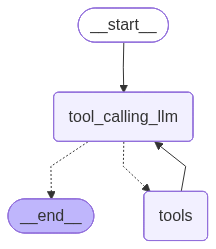

In [40]:
graph1

In [41]:
response4 = graph1.invoke({"messages" : "What is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response4["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  multiply (az51c2mvm)
 Call ID: az51c2mvm
  Args:
    a: 2
    b: 5
  multiply (kp2ybc5e9)
 Call ID: kp2ybc5e9
  Args:
    a: 10
    b: 100
================================= Tool Message =================================
Name: multiply

10
================================= Tool Message =================================
Name: multiply

1000
================================== Ai Message ==================================

So, 2 multiplied by 5 is 10, and 10 multiplied by 100 is 1000.


In [42]:
response5 = graph1.invoke({"messages" : "What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step"})
for m in response5["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is the latest news by Apple Inc. and what is 2 multiplied by 5 and then multipled by 100 ? - go step by step
================================== Ai Message ==================================
Tool Calls:
  tavily_search (nx3y3a742)
 Call ID: nx3y3a742
  Args:
    end_date: None
    exclude_domains: []
    include_domains: ['apple.com']
    include_images: False
    query: Apple Inc latest news
    search_depth: advanced
    start_date: None
    topic: news
  multiply (wknpwhbm9)
 Call ID: wknpwhbm9
  Args:
    a: 2
    b: 5
================================= Tool Message =================================
Name: tavily_search

{"query": "Apple Inc latest news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.apple.com/newsroom/2026/04/apple-reports-second-quarter-results/", "title": "Apple reports second quarter results - Apple", "score": 0.9678993, "published_d

<br>

## Adding Memory in Agentic Graph

In [43]:
response6 = graph1.invoke({"messages" : "Hi! This is Rick!!"})
for m in response6["messages"]:
  m.pretty_print()

================================ Human Message =================================

Hi! This is Rick!!
================================== Ai Message ==================================

Welcome to the conversation, Rick! It's great to meet you. Is there something I can help you with or would you like to chat?


In [44]:
response7 = graph1.invoke({"messages" : "What is my name ?"})
for m in response7["messages"]:
  m.pretty_print()

================================ Human Message =================================

What is my name ?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (k5qz9bsag)
 Call ID: k5qz9bsag
  Args:
    end_date: None
    exclude_domains: None
    include_domains: None
    include_images: False
    query: self name
    search_depth: basic
    start_date: None
    time_range: None
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "self name", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.wisdomlib.org/names/self", "title": "Meaning of the name Self", "content": "The name \"Self\" is an English surname derived from the Middle English word \"self,\" meaning \"one's own person\" or \"the person in question.\" It", "score": 0.7876867, "raw_content": null}, {"url": "https://en.wiktionary.org/wiki/selfname", "title": "

In [45]:
'''
You see, the conversation is never stored / recorded - i.e., no persistency on conversation (memory)
'''

'\nYou see, the conversation is never stored / recorded - i.e., no persistency on conversation (memory)\n'

In [ ]:
# Working around the same graph that we used before

from langgraph.checkpoint.memory import MemorySaver

# Creating the memory object
memory = MemorySaver()

# Creating the Graph (Adding Nodes)
builder2 = StateGraph(State)
builder2.add_node("tool_calling_llm", tool_calling_llm)
builder2.add_node("tools", ToolNode(tools))

# Adding Edges
builder2.add_edge(START, "tool_calling_llm")
builder2.add_conditional_edges(
  "tool_calling_llm",
  # If the latest message (result) from assistant is a tool call --> tools_condition routes to tools
  # If the latest message (result) from assistant is a NOT a tool call --> tools_condition routes to END
  tools_condition
)
builder2.add_edge("tools", "tool_calling_llm")

# Compiling the graph
graph2 = builder2.compile(checkpointer = memory)

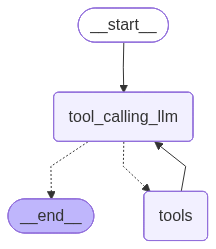

In [47]:
graph2

In [48]:
'''
For creating memory (say for a session) - we need a Thread ID
Thread ID is responsbile to uniquely identify every other session
'''

config = {"configurable" : {"thread_id" : "1"}}

response_memory = graph2.invoke({"messages" : "Hi! This is Soubhik Sinha!!"}, config = config)
response_memory


{'messages': [HumanMessage(content='Hi! This is Soubhik Sinha!!', additional_kwargs={}, response_metadata={}, id='b76704cb-1c29-41c3-af27-b93f4bde565a'),
  AIMessage(content='Nice to meet you, Soubhik Sinha! What brings you here today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1756, 'total_tokens': 1775, 'completion_time': 0.030294441, 'completion_tokens_details': None, 'prompt_time': 0.184700178, 'prompt_tokens_details': None, 'queue_time': 0.219217162, 'total_time': 0.214994619}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfac0-e101-78a1-a2e3-89f0cb2ac9e1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1756, 'output_tokens': 19, 'total_tokens': 1775})]}

In [49]:
response_memory["messages"][-1].content

'Nice to meet you, Soubhik Sinha! What brings you here today?'

In [50]:
response_memory = graph2.invoke({"messages" : "What is my name ?"}, config = config)

response_memory["messages"][-1].content

'Your name is Soubhik Sinha.'

In [52]:
response_memory = graph2.invoke({"messages" : "Do you still remember my name ?"}, config = config)

response_memory["messages"][-1].content

'Soubhik Sinha'

<br>

## Streaming

In [53]:
'''
Streaming in a LangGraph agentic workflow refers to the capability to receive real-time, incremental updates as an agent executes, rather than waiting for the entire process to finish
'''

'\nStreaming in a LangGraph agentic workflow refers to the capability to receive real-time, incremental updates as an agent executes, rather than waiting for the entire process to finish\n'

In [54]:
def superBot(state: State):
  return {"messages": [llm.invoke(state["messages"])]}

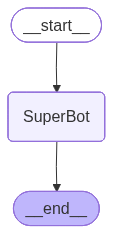

In [57]:
# Creating the graph

graph3 = StateGraph(State)

# Creating memory object
memory_1 = MemorySaver()

# Adding nodes
graph3.add_node("SuperBot", superBot)

# Adding Edges
graph3.add_edge(START, "SuperBot")
graph3.add_edge("SuperBot", END)

# Compiling the Graph
graph_builder_1 = graph3.compile(checkpointer = memory_1)

# Displaying the graph
graph_builder_1

In [ ]:
# Invocation using creation of thread

config_1 = {"configurable" : {"thread_id": "1"}}

graph_builder_1.invoke({"messages" : "Hi! This is Rick!! I am an AI Engineer"}, config = config)

{'messages': [HumanMessage(content='Hi! This is Rick!! I am an AI Engineer', additional_kwargs={}, response_metadata={}, id='e6576ac4-3602-4c2a-8149-e781ded28099'),
  AIMessage(content="Hello Rick! Nice to meet you, an AI Engineer, that's awesome! What brings you here today? Are you working on a new project, or do you have some questions about AI engineering? I'm here to help and chat with you about anything related to AI, machine learning, or software development. What's on your mind?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 69, 'prompt_tokens': 46, 'total_tokens': 115, 'completion_time': 0.142395164, 'completion_tokens_details': None, 'prompt_time': 0.003878144, 'prompt_tokens_details': None, 'queue_time': 0.007062089, 'total_time': 0.146273308}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_020e283281', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dfad8-098d-